In [ ]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
import numpy as np
import scipy.special as sp

class pr_absorb(object):
    def __init__(self,**kwargs):
        self.d = kwargs.get("d", 3)
        self.nu = (self.d-2)/2

    def __call__(self, cr2):
        return np.power(np.sqrt(cr2),self.nu)/(np.power(2,self.nu)*sp.gamma(self.nu+1)*sp.iv(self.nu,np.sqrt(cr2)))

$\begin{cases}\Delta u = cu +f & \Omega\\ u=g &\partial\Omega\end{cases}$

In [166]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [167]:
def Green(r, R):
    return np.log(R/r)/(2 * math.pi)

In [168]:
sample_map = np.zeros((100000, 2))
for i in range(1, 100001):
    sample_map[i-1][1] = i/100000
    sample_map[i-1][0] = -2*(i/100000)**2*math.log(i/100000) + (i/100000)**2

In [169]:
def sampling(r, x0, sample_map):
    x = random.uniform(0, 1)
    s = sample_map[np.argmin(abs(sample_map[:, 0] - x))][1]
    source_r = s * r
    source_theta = random.uniform(0, 2*math.pi)
    source_local = x0 + np.array([source_r * math.cos(source_theta), source_r * math.sin(source_theta)])
    return source_local

In [ ]:
pr = pr_absorb(d=2)
c = .2
def pathGenerator(v, segments, g, f, sample_map, eps = 0.001, maxSteps = 16, maxR = 10):
    x0 = v
    path = []
    source = 0
    absorbed = 1
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        absorbed *= 1 if (pr(c*r*r)>=np.random.uniform(0, 1, 1)) else 0
        if r < eps and len(path) > 0: 
            return path, g(x0)*absorbed - source
        ### source term sample and record
        source_local = sampling(r, x0, sample_map)
        source += absorbed *r * r * f(source_local)/4
        
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
    return [], 0

$\begin{cases}\Delta u = cu +2x-cxy^2 & \Omega\\ u=xy^2 + e^{\sqrt{c}x} &\partial\Omega\end{cases}$

In [171]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 1]]), np.array([[-1, 1], [1, 1]])]

#v = np.array([0, 0])
'''
problem set-up: xyy
'''
def boundary(v):
    return v[0] * v[1] * v[1] + np.exp(np.sqrt(c)*v[0])

def source(v): 
    return 2*v[0]-c*v[0]*v[1]*v[1]

In [172]:
pathGenerator(np.array([0, 0]), segments, boundary, source, sample_map)

([array([0, 0]),
  array([-0.9906803,  0.1362077]),
  array([-0.98305603,  0.13084792]),
  array([-0.9885639 ,  0.14687169]),
  array([-0.99981273,  0.14893283])],
 0.7025648105735247)

In [173]:
##### evenly distributed start places
#target = []
#width = range(1, 220)
#height = range(1, 220)
#for i in width:
#    for j in height:
#        target.append(np.array([i/110 - 1, j/110 - 1]))

#print(len(target))

###### pure random start places
# target = np.random.rand(40000, 2)
# target = 2* target - 1

#####QMC start places
import scipy.stats as stats
qmcGenerator = stats.qmc.Sobol(d=2)
target = qmcGenerator.random(n=40000)
target = 2* target - 1

In [174]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = pathGenerator(v, segments, boundary, source, sample_map)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)


In [175]:
paths1 = np.zeros((len(paths), maxPath, 2))
for i in range(len(paths)):
    path = paths[i]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 2)) * np.array(path[len(path) - 1])))

    paths1[i] = npath

print(paths1.shape)

(33485, 16, 2)


In [176]:
paths1[760]

array([[ 0.14168108, -0.95364858],
       [ 0.09709856, -0.96633134],
       [ 0.12999618, -0.95916722],
       [ 0.08947699, -0.95411641],
       [ 0.09967713, -0.99885186],
       [ 0.10080508, -0.99863749],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191],
       [ 0.10133693, -0.99989191]])

In [177]:
paths1 = paths1.reshape(-1, 16, 2).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

In [178]:
class NN(keras.Model):
    def __init__(self, units):
        super(NN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(3)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [179]:
class Ysolver1(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layer):
        super(Ysolver1, self).__init__()
        self.model = NN(layer)

        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training, batch):
        #print(path.shape)
        y_pred = self.model(path[:, 0], training)[:, 0]
        #print(y_pred.shape)
        for i in range(15): ###input path should be (-1, 2) shaped nparray, no len()
            #y = self.Ymodel(path[:, i], training)
            #print(y.shape)
            #z_input = tf.concat([path[:, i],y], 1)
            z = self.model(path[:, i], training)[:, 1:3] #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            add = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1] #accumulating
            #print(add.shape)
            y_pred += add

        return y_pred

In [180]:
class NNsolver1(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver1, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver1([32, 64, 128])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=3e-4 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.reduce_mean(tf.square(delta))
        return loss

    def train_step(self, cur_path, training, batch_size):           
        return self.model(cur_path, training, batch_size)

    def train(self, batch_size): 
        training_history = []
        for i in range((len(self.paths) - 1)//batch_size + 1):
            batch = batch_size
            if (i + 1) * batch_size > len(paths):
                batch = len(paths) - i * batch_size
            cur_path = self.paths[i*batch_size: i*batch_size + batch]
            cur_bound = self.boundary[i*batch_size: i*batch_size + batch]
                
            with tf.GradientTape() as tape:
                y_pred = self.train_step(cur_path, training = True, batch_size=batch)
                loss = self.loss_fn(y_pred, cur_bound)

            training_vars = self.model.trainable_variables 
            grad = tape.gradient(loss, training_vars)
            #print(grad)
            #print("----------------------------------------------------")
            self.optimizer.apply_gradients(zip(grad, training_vars))
            #print(self.model.Ymodel.trainable_variables)
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch, batch_size):
        for i in range(epoch):
            cur_history = self.train(batch_size)
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [181]:
training = NNsolver1(paths1, boundary1)
training.train_epoch(50, 1024)

epoch: 0 loss: 1.2647614
epoch: 1 loss: 0.5495009
epoch: 2 loss: 0.19071165
epoch: 3 loss: 0.13797826
epoch: 4 loss: 0.11845968
epoch: 5 loss: 0.10142603
epoch: 6 loss: 0.085580945
epoch: 7 loss: 0.072541244
epoch: 8 loss: 0.06292092
epoch: 9 loss: 0.056863476
epoch: 10 loss: 0.053574927
epoch: 11 loss: 0.051730163
epoch: 12 loss: 0.0506003
epoch: 13 loss: 0.049786735
epoch: 14 loss: 0.049141638
epoch: 15 loss: 0.048589732
epoch: 16 loss: 0.048098613
epoch: 17 loss: 0.047677808
epoch: 18 loss: 0.047298595
epoch: 19 loss: 0.046956036
epoch: 20 loss: 0.0466433
epoch: 21 loss: 0.046360273
epoch: 22 loss: 0.04610173
epoch: 23 loss: 0.045861773
epoch: 24 loss: 0.045637544
epoch: 25 loss: 0.045433182
epoch: 26 loss: 0.045243174
epoch: 27 loss: 0.04506898
epoch: 28 loss: 0.044905707
epoch: 29 loss: 0.04475584
epoch: 30 loss: 0.044616904
epoch: 31 loss: 0.04449023
epoch: 32 loss: 0.044373613
epoch: 33 loss: 0.044269677
epoch: 34 loss: 0.044170637
epoch: 35 loss: 0.044074763
epoch: 36 loss: 0.0

In [182]:
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        Z.append(training.model.model(np.array([i/50 - 1 ,j/50 - 1]).reshape([1, 2]).astype("float32")))

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)


In [183]:
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)

(101, 101)
0.06284117600230538 0.019795769422122855


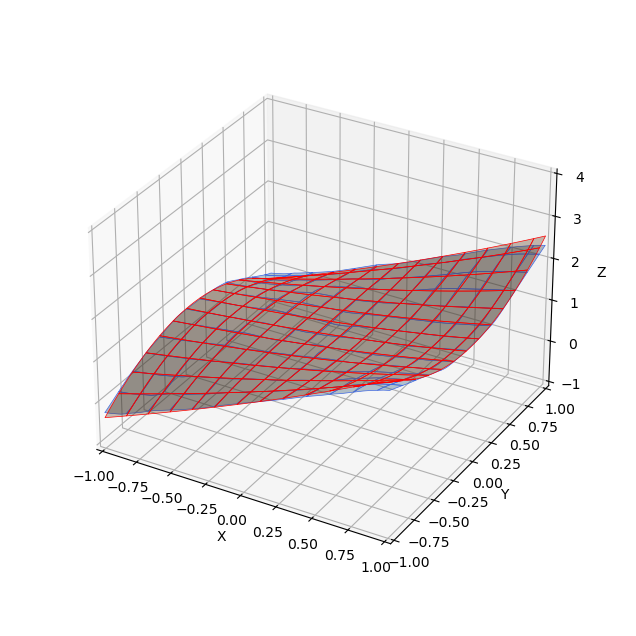

In [184]:
Z1 = Y*Y*X+ np.exp(np.sqrt(c)*X)
print(Z1.shape)

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 4),
       xlabel='X', ylabel='Y', zlabel='Z')

ax.set_box_aspect(None, zoom=0.85)
# ax.set_title("Fig7: WoSNN with randomly distributed start places for 2D Poisson", y=-0.01)
#plt.show()
plt.savefig('WoSNNMC2Dpoisson_c.png', bbox_inches='tight')
print(np.power((Z1-Z2),2).sum()/np.power(Z1,2).sum()*100, np.abs(Z1-Z2).sum()/(101*101))

(101, 101)
1.242830463338419 0.09264913503734079


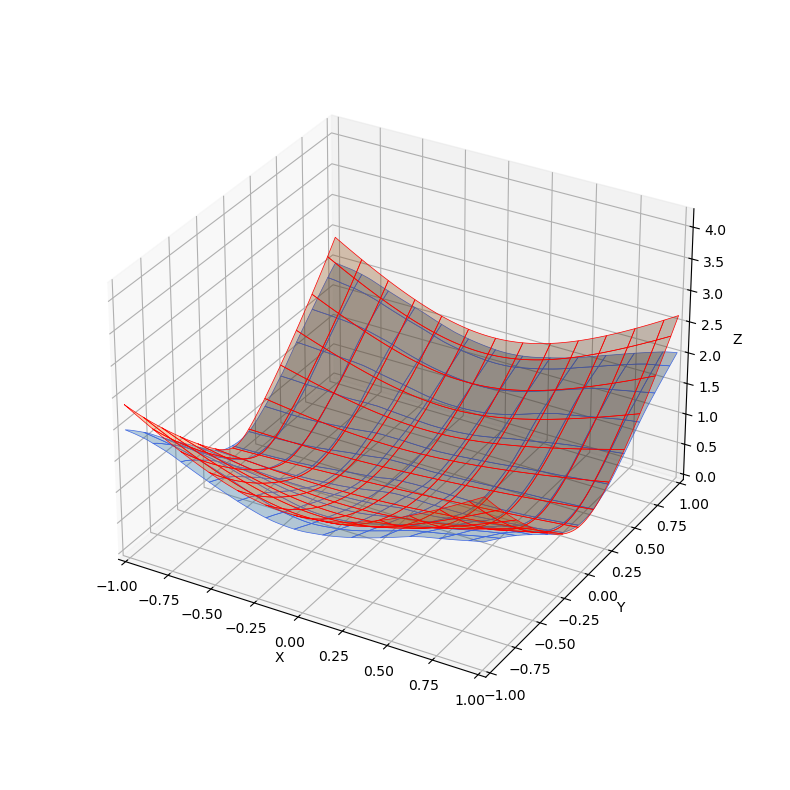

In [185]:
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:3].reshape(-1, 2), axis = 1).reshape(101, 101)
Z1 = np.sqrt(np.power(Y*Y+ np.sqrt(c)*np.exp(np.sqrt(c)*X),2)+ np.power(2*X*Y,2))
print(Z1.shape)

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 4.2),
       xlabel='X', ylabel='Y', zlabel='Z')

ax.set_box_aspect(None, zoom=0.85)
# ax.set_title("Fig8: WoSNN gradient approximation with randomly distributed start places for 2D Poisson", y=-0.01)
plt.tight_layout();
plt.savefig('WoSNNMC2DpoissonXGradient_c.png', bbox_inches='tight')
print(np.power((Z1-Z3),2).sum()/np.power(Z1,2).sum()*100, np.abs(Z1-Z3).sum()/(101*101))

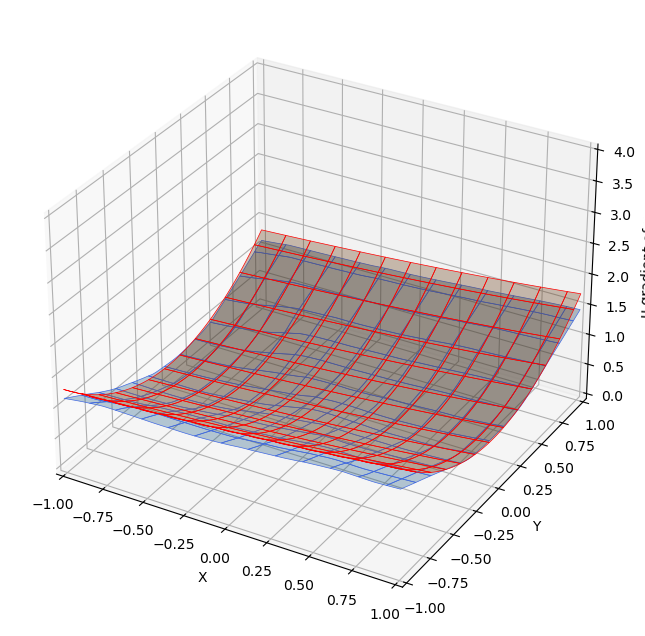

In [186]:
X1 = np.array(Z)[:, :, 1].reshape(101, 101)
X2 = Y*Y+ np.sqrt(c)*np.exp(np.sqrt(c)*X)

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, X1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of x')
ax.plot_surface(X, Y, X2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 4),
       xlabel='X', ylabel='Y', zlabel='u gradient of x')


#ax.set_box_aspect(None, zoom=0.85)
#ax.set_title("Fig10: WoSNN x's gradient with evenly distributed start places for 2D Poisson", y=-0.01)
plt.show()
#plt.savefig('WoSNNeven2DpoissonXGradient.png', bbox_inches='tight')

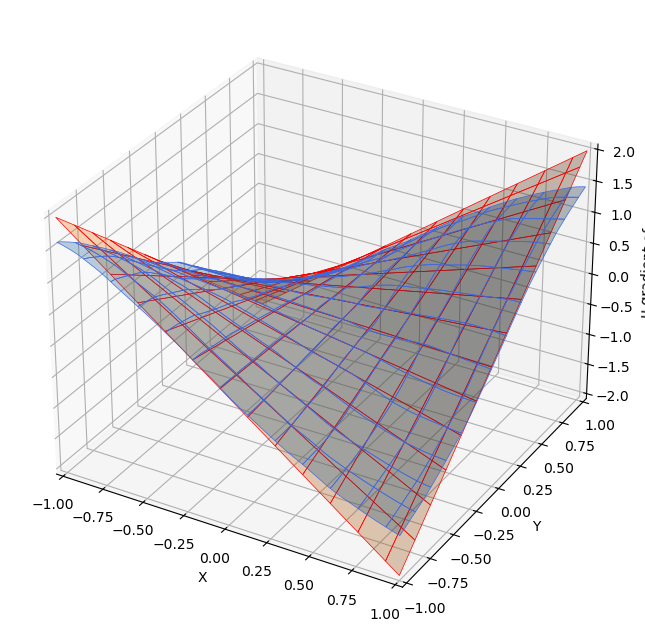

In [187]:
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = 2*X*Y

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of y')
ax.plot_surface(X, Y, Y2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-2, 2),
       xlabel='X', ylabel='Y', zlabel='u gradient of y')

#ax.set_box_aspect(None, zoom=0.85)
#ax.set_title("Fig11: WoSNN y's gradient with evenly distributed start places for 2D Poisson", y=-0.01)
plt.show()
#plt.savefig('WoSNNeven2DpoissonYGradient.png', bbox_inches='tight')